# 01 - Dataset exploration: GSE298774

Week 1 deliverable. This notebook regenerates every number in
`docs/dataset_description.md` directly from the downloaded files - it is the
source of truth if the two ever differ (see that file's header). It also
runs the structural checks that `src/geo_loading.py` relies on, so a change
to the deposit or the loader would show up here first.

Scope for this notebook: inventory the 19 libraries, verify the loader
against the real data, build the per-library QC table, and check whether
library A2 is usable (spot-over-image overlay). No clustering, DE, or
biological interpretation here - that starts in notebook 02 onward, on
QC'd data.


In [1]:
import sys
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
import geo_loading as gl

RAW = Path("..") / "data" / "raw"
SUPPL_XLSX = RAW / "supplementary" / "can-25-2934_supplementary_tables_suppst1.xlsx"
TABLES_OUT = Path("..") / "results" / "tables"
FIGURES_OUT = Path("..") / "results" / "figures"
TABLES_OUT.mkdir(parents=True, exist_ok=True)
FIGURES_OUT.mkdir(parents=True, exist_ok=True)

sc.settings.verbosity = 1
plt.rcParams["figure.facecolor"] = "white"


## 1. Files on disk

One row per library, parsed from the flat `<GSM>_<library>_<file>.gz` naming.

In [2]:
libs_df = gl.list_libraries(RAW)
print(f"{len(libs_df)} libraries across {libs_df['gsm'].nunique()} GEO samples (slides)")
libs_df


19 libraries across 11 GEO samples (slides)


,gsm,library,has_barcodes,has_features
0,GSM9022963,A17,True,True
1,GSM9022963,A2,False,False
2,GSM9022964,A7,True,True
3,GSM9022965,A21,True,True
4,GSM9022966,A16,True,True
5,GSM9022966,A23,True,True
6,GSM9022967,A22,True,True
7,GSM9022967,A24,True,True
8,GSM9022968,A34,True,True
9,GSM9022969,B1,True,True


## 2. Loading all 19 libraries

`load_all` applies the loader's handling of shared slide-level matrices, the
two gene panels, and A2's inferred/zero-filled barcodes (see
`src/geo_loading.py` docstring). Loading with images enabled so the same pass
can be reused for the spot-over-image overlays in section 6.

In [3]:
%%time
adatas = gl.load_all(RAW, only_in_tissue=True, load_images=True)
print(f"loaded {len(adatas)} libraries")


loaded 19 libraries
CPU times: total: 1min 22s
Wall time: 58.8 s


## 3. Structural checks

These reproduce the claims in `docs/dataset_description.md` against the data
actually loaded above, instead of re-asserting them as given facts.

In [4]:
# 3a. every library's spot count against its own tissue_positions.csv in_tissue count
rows = []
for lib, a in sorted(adatas.items()):
    pos = gl.read_positions(RAW / f"{libs_df.set_index('library').loc[lib, 'gsm']}_{lib}_tissue_positions.csv.gz")
    expected = int((pos["in_tissue"] == 1).sum())
    rows.append({"library": lib, "n_obs": a.n_obs, "expected_in_tissue": expected,
                 "match": a.n_obs == expected})
check_df = pd.DataFrame(rows)
print(check_df.to_string(index=False))
assert check_df["match"].all(), "some library's loaded spot count disagrees with its own tissue_positions.csv"
print("\nAll 19 libraries match their own declared in-tissue spot count.")


library  n_obs  expected_in_tissue  match
    A16   5195                5195   True
    A17   2274                2274   True
     A2   3367                3367   True
    A21   2260                2260   True
    A22   4326                4326   True
    A23   2782                2782   True
    A24   6165                6165   True
    A34   4151                4151   True
     A7   2892                2892   True
     B1   3952                3952   True
    B13   3614                3614   True
    B14   2206                2206   True
    B15   3171                3171   True
  B38_2   2100                2100   True
  B38ex   1861                1861   True
     B4   6415                6415   True
     B8   5780                5780   True
    D20   1089                1089   True
     D3   1501                1501   True

All 19 libraries match their own declared in-tissue spot count.


In [5]:
# 3b. gene panels actually present, per library (not asserted from the paper - counted)
panel_counts = pd.Series({lib: a.n_vars for lib, a in adatas.items()}).value_counts()
print("Feature panel sizes across libraries:")
print(panel_counts)
for panel_size in panel_counts.index:
    libs_with_panel = sorted(lib for lib, a in adatas.items() if a.n_vars == panel_size)
    print(f"  {panel_size} features: {libs_with_panel}")


Feature panel sizes across libraries:
37082    16
18085     3
Name: count, dtype: int64
  37082 features: ['A17', 'A2', 'A22', 'A24', 'A34', 'A7', 'B1', 'B13', 'B14', 'B15', 'B38_2', 'B38ex', 'B4', 'B8', 'D20', 'D3']
  18085 features: ['A16', 'A21', 'A23']


In [6]:
# 3c. A2's inferred/zero-filled barcodes
a2 = adatas["A2"]
n_inferred = int(a2.obs["barcodes_inferred"].sum())
n_zero_filled = int(a2.obs["expression_zero_filled"].sum())
print(f"A2: {a2.n_obs} in-tissue spots total, {n_inferred} with barcodes recovered from sibling A17, "
      f"{n_zero_filled} of those with no non-zero column match (loaded as explicit all-zero rows).")
other_inferred = {lib: int(a.obs['barcodes_inferred'].sum()) for lib, a in adatas.items() if lib != "A2"}
assert all(v == 0 for v in other_inferred.values()), "unexpected inferred barcodes outside A2"
print("No other library needed barcode inference.")


A2: 3367 in-tissue spots total, 3367 with barcodes recovered from sibling A17, 42 of those with no non-zero column match (loaded as explicit all-zero rows).
No other library needed barcode inference.


In [7]:
# 3d. shared slide-level matrices: which sibling groups are byte-identical on disk
def md5(path):
    return hashlib.md5(Path(path).read_bytes()).hexdigest()

multi_lib_gsms = libs_df.groupby("gsm")["library"].apply(list)
multi_lib_gsms = multi_lib_gsms[multi_lib_gsms.apply(len) > 1]
for gsmid, libs in multi_lib_gsms.items():
    hashes = {lib: md5(RAW / f"{gsmid}_{lib}_matrix.mtx.gz") for lib in libs}
    shapes = {lib: gl.read_matrix(RAW / f"{gsmid}_{lib}_matrix.mtx.gz").shape for lib in libs}
    identical = len(set(hashes.values())) == 1
    print(f"{gsmid} {libs}: byte-identical matrix file = {identical}; shapes = {shapes}")


GSM9022963 ['A17', 'A2']: byte-identical matrix file = False; shapes = {'A17': (37082, 13887), 'A2': (37082, 13916)}


GSM9022966 ['A16', 'A23']: byte-identical matrix file = False; shapes = {'A16': (18085, 5195), 'A23': (18085, 2782)}


GSM9022967 ['A22', 'A24']: byte-identical matrix file = False; shapes = {'A22': (37082, 14336), 'A24': (37082, 14335)}


GSM9022969 ['B1', 'B38ex']: byte-identical matrix file = True; shapes = {'B1': (37082, 14328), 'B38ex': (37082, 14328)}


GSM9022971 ['B13', 'B8']: byte-identical matrix file = True; shapes = {'B13': (37082, 14210), 'B8': (37082, 14210)}


GSM9022972 ['B14', 'B15', 'B38_2']: byte-identical matrix file = True; shapes = {'B14': (37082, 14145), 'B15': (37082, 14145), 'B38_2': (37082, 14145)}


GSM9022973 ['D20', 'D3']: byte-identical matrix file = True; shapes = {'D20': (37082, 4991), 'D3': (37082, 4991)}


Groups reported as `byte-identical = False` above either ship a genuinely
per-library matrix (A16/A23 - each already only contains its own spots), or
ship matrices that agree on their non-zero columns but not byte-for-byte
(A2/A17, A22/A24 - a handful of columns present in one library's file but not
the other's; `src/geo_loading.py`'s `infer_missing_barcodes` checks this
entry-by-entry for A2 and would have raised `ValueError` in section 2 above
if the data disagreed - it didn't).

## 4. Patient / lesion mapping (Supplementary Table S1)

In [8]:
s1 = pd.read_excel(SUPPL_XLSX, sheet_name="Supplementary Table S1", header=4)
s1 = s1.rename(columns={"Visium ID": "library", "Patient#": "patient"})
s1["library"] = s1["library"].astype(str).str.strip()
# the source spreadsheet has a stray non-breaking space (U+00A0) in some Patient# cells
# (e.g. '\xa03' instead of '3') - strip it so it doesn't leak into our own output
s1["patient"] = s1["patient"].astype(str).str.replace("\xa0", "", regex=False).str.strip().astype(int)
s1 = s1.set_index("library")
print(f"{len(s1)} lesions listed in Supplementary Table S1")
s1[["patient", "Sex", "Age at time of diagnosis", "Anatomical location",
    "Melanoma stage", "WHO classification"]]


18 lesions listed in Supplementary Table S1


,patient,Sex,Age at time of diagnosis,Anatomical location,Melanoma stage,WHO classification
library,,,,,,
B1,1,Male,48,mid back,"T3aN0M0, Stage IIA",(I) Low CSD melanoma
A2,2,Female,49,shoulder,"T1aN0M0, Stage IA",(I) Low CSD melanoma
D3,3,Female,41,"face, jaw","T1aN0M0, Stage IA",(I) Low CSD melanoma
B4,4,Male,72,upper back,"T2aN0M0, Stage IB",(I) Low CSD melanoma
A7,7,Female,31,lower back,"T1bN0M0, Stage IA",(I) Low CSD melanoma
B8,8,Male,62,mid back,"T1aN0M0, Stage IA",(I) Low CSD melanoma
B13,13,Female,38,"face, temporal","T3bN3cM0, Stage IIIC",(I) Low CSD melanoma
B14,14,Female,47,upper arm,"T1bN0M0, Stage IA",(I) Low CSD melanoma
B15,15,Female,53,back,"T2aN0M0, Stage IB",(I) Low CSD melanoma


In [9]:
# every loaded library should have a row here (B38ex/B38_2 both map to the same
# patient# in this table, since S1 lists one row per patient/lesion)
missing_from_s1 = sorted(set(adatas) - set(s1.index) - {"B38ex", "B38_2"})
print("Libraries loaded but absent from S1 (other than the B38 split):", missing_from_s1)
print()
print("Patient 38's two libraries (from file naming, not in S1 directly):")
print("  B38ex, B38_2 -> both patient 38 per docs/dataset_description.md (S1 lists only 'B38')")
n_patients = s1["patient"].nunique() if "B38" not in s1.index else s1.loc[s1.index != "B38", "patient"].nunique() + 1
print(f"{len(adatas)} libraries loaded; {s1['patient'].nunique()} distinct patient numbers in S1 "
      "(B38ex/B38_2 count as one patient, so 19 libraries / 18 patients matches the docs)")


Libraries loaded but absent from S1 (other than the B38 split): []

Patient 38's two libraries (from file naming, not in S1 directly):
  B38ex, B38_2 -> both patient 38 per docs/dataset_description.md (S1 lists only 'B38')
19 libraries loaded; 18 distinct patient numbers in S1 (B38ex/B38_2 count as one patient, so 19 libraries / 18 patients matches the docs)


## 5. Per-library QC metrics

In [10]:
for a in adatas.values():
    a.var["mt"] = a.var_names.str.startswith("MT-")
    sc.pp.calculate_qc_metrics(a, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

def lookup_patient(lib):
    if lib in s1.index:
        return s1.loc[lib, "patient"]
    if lib in ("B38ex", "B38_2") and "B38" in s1.index:
        return s1.loc["B38", "patient"]
    return None

qc_rows = []
for lib, a in sorted(adatas.items()):
    gsm = libs_df.set_index("library").loc[lib, "gsm"]
    patient = lookup_patient(lib)
    qc_rows.append({
        "library": lib,
        "gsm": gsm,
        "patient": patient,
        "n_spots_in_tissue": a.n_obs,
        "feature_panel_size": a.n_vars,
        "n_genes_detected": int((np.asarray(a.X.sum(axis=0)).ravel() > 0).sum()),
        "median_genes_per_spot": float(np.median(a.obs["n_genes_by_counts"])),
        "median_umis_per_spot": float(np.median(a.obs["total_counts"])),
        # pct_counts_mt is 0/0 = NaN for a zero-total-count spot (only possible for A2's
        # zero-filled spots); nanmedian so one library's undefined values don't blank the row
        "median_pct_mito": float(np.nanmedian(a.obs["pct_counts_mt"])),
        "n_spots_with_undefined_pct_mito": int(a.obs["pct_counts_mt"].isna().sum()),
        "spots_below_500_genes": int((a.obs["n_genes_by_counts"] < 500).sum()),
        "barcodes_inferred": bool(a.obs["barcodes_inferred"].any()),
        "n_zero_filled_spots": int(a.obs["expression_zero_filled"].sum()),
    })
library_inventory = pd.DataFrame(qc_rows).sort_values("median_genes_per_spot")
library_inventory.to_csv(TABLES_OUT / "library_inventory.csv", index=False)
print(f"wrote {TABLES_OUT / 'library_inventory.csv'}")
library_inventory


wrote ..\results\tables\library_inventory.csv


,library,gsm,patient,n_spots_in_tissue,feature_panel_size,n_genes_detected,median_genes_per_spot,median_umis_per_spot,median_pct_mito,n_spots_with_undefined_pct_mito,spots_below_500_genes,barcodes_inferred,n_zero_filled_spots
2,A2,GSM9022963,2,3367,37082,17445,35.0,57.0,3.225806,42,3143,True,42
16,B8,GSM9022971,8,5780,37082,18715,70.0,128.0,3.896104,0,4902,False,0
11,B14,GSM9022972,14,2206,37082,17236,147.0,265.0,2.366864,0,1537,False,0
12,B15,GSM9022972,15,3171,37082,18530,151.0,288.0,5.607476,0,2100,False,0
1,A17,GSM9022963,17,2274,37082,18435,243.5,410.0,4.081633,0,1410,False,0
7,A34,GSM9022968,34,4151,37082,18521,300.0,507.0,3.000000,0,2520,False,0
8,A7,GSM9022964,7,2892,37082,18944,377.5,460.0,5.249189,1,1603,False,0
10,B13,GSM9022971,13,3614,37082,18728,402.0,752.0,2.657328,0,2073,False,0
13,B38_2,GSM9022972,38,2100,37082,18818,533.0,1084.5,3.137338,0,1006,False,0
0,A16,GSM9022966,16,5195,18085,18054,554.0,1246.0,4.069767,0,2424,False,0


## 6. QC distributions

Sorted by median genes/spot to make the depth spread across libraries
visible directly, rather than restating the number from the docs.

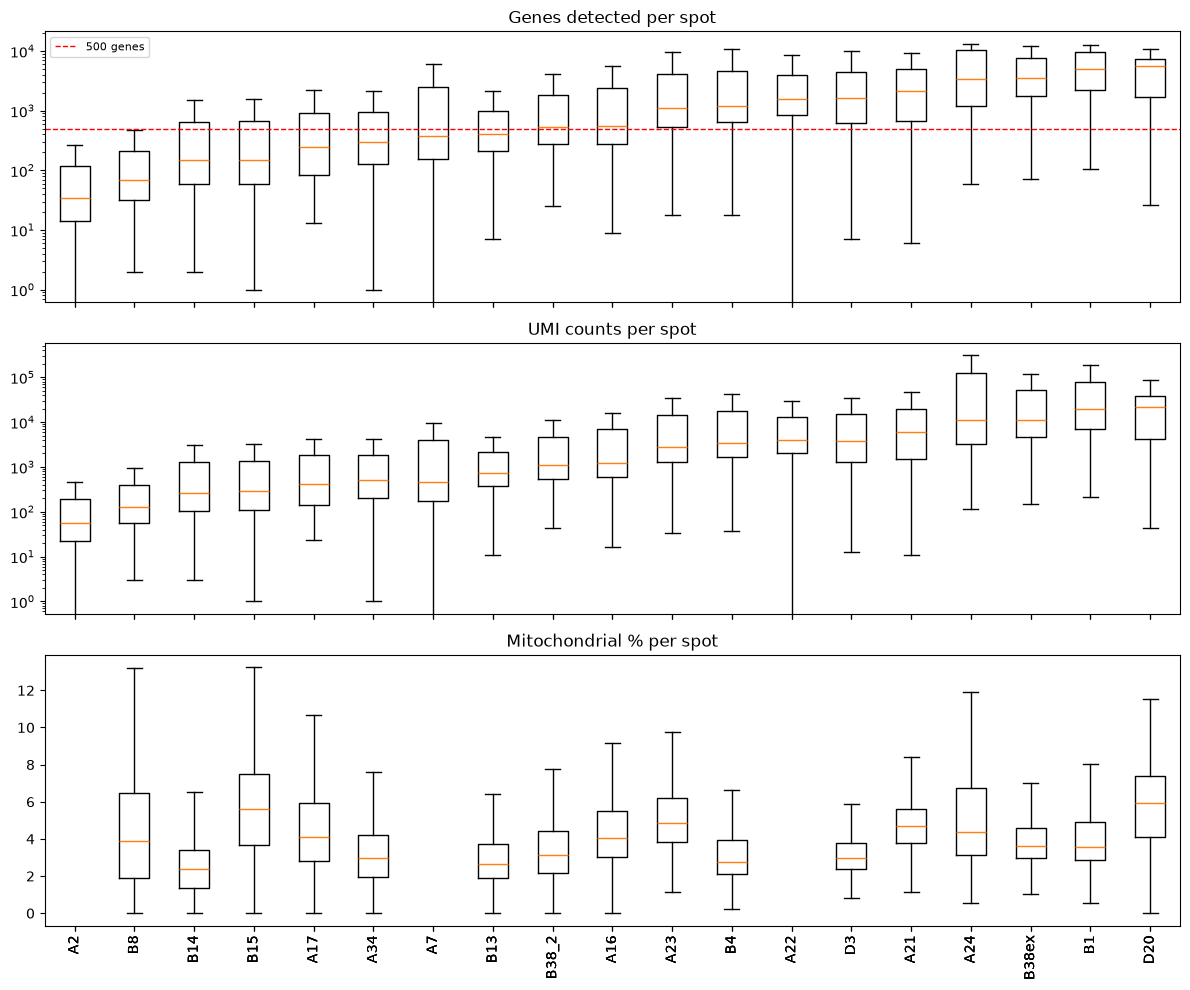

In [11]:
order = library_inventory["library"].tolist()
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, col, title, logy in [
    (axes[0], "n_genes_by_counts", "Genes detected per spot", True),
    (axes[1], "total_counts", "UMI counts per spot", True),
    (axes[2], "pct_counts_mt", "Mitochondrial % per spot", False),
]:
    data = [adatas[lib].obs[col].values for lib in order]
    ax.boxplot(data, tick_labels=order, showfliers=False)
    ax.set_title(title)
    if logy:
        ax.set_yscale("log")
axes[0].axhline(500, color="red", linestyle="--", linewidth=1, label="500 genes")
axes[0].legend(loc="upper left", fontsize=8)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(FIGURES_OUT / "01_qc_distributions_by_library.png", dpi=150)
plt.show()


## 7. Spot-over-image overlays

The main question: is A2 a failed library, or a coordinate mismatch? Overlay
A2 and its sibling A17 (same slide, GSM9022963) on the same tissue image.

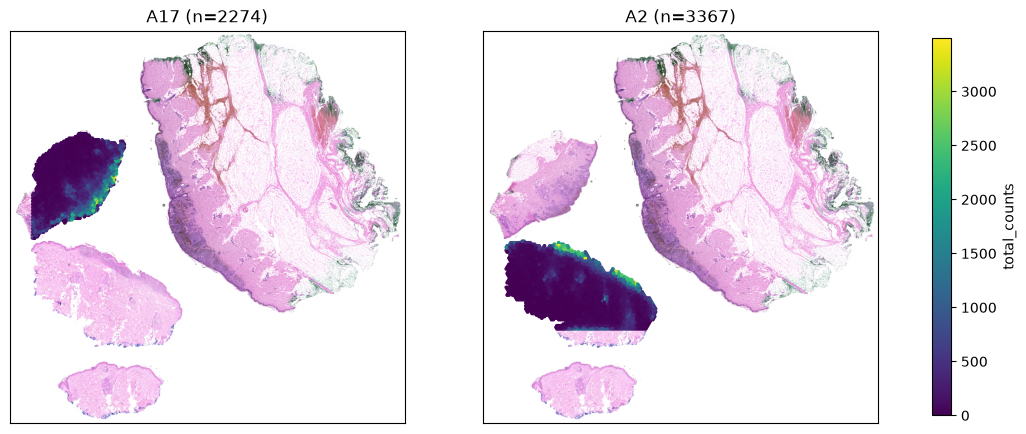

In [12]:
def plot_overlay(ax, adata, title, color_by="total_counts", vmax=None):
    img = adata.uns["spatial"][adata.obs["library"].iloc[0]]["images"]["hires"]
    sf = adata.uns["spatial"][adata.obs["library"].iloc[0]]["scalefactors"]["tissue_hires_scalef"]
    ax.imshow(img)
    xy = adata.obsm["spatial"] * sf
    c = adata.obs[color_by]
    sca = ax.scatter(xy[:, 0], xy[:, 1], c=c, s=3, cmap="viridis", vmax=vmax)
    ax.set_title(f"{title} (n={adata.n_obs})")
    ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
    return sca

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
plot_overlay(axes[0], adatas["A17"], "A17")
sca = plot_overlay(axes[1], adatas["A2"], "A2")
fig.colorbar(sca, ax=axes, label="total_counts", shrink=0.7)
plt.savefig(FIGURES_OUT / "01_A2_vs_A17_spatial_overlay.png", dpi=150, bbox_inches="tight")
plt.show()


**Observed:** A2's spot mask clearly extends past the visible tissue outline
in the image, into blank background below/left of the tissue piece A17 also
sits on. Only the strip where A2's mask overlaps actual tissue (top edge)
shows appreciable signal (green/yellow); the rest, sitting on blank image
background, is uniformly near-zero. Compare against every other library in
the next figure - all of them hug their own tissue piece's outline tightly,
with no equivalent overhang. A2 is the only library that does this.

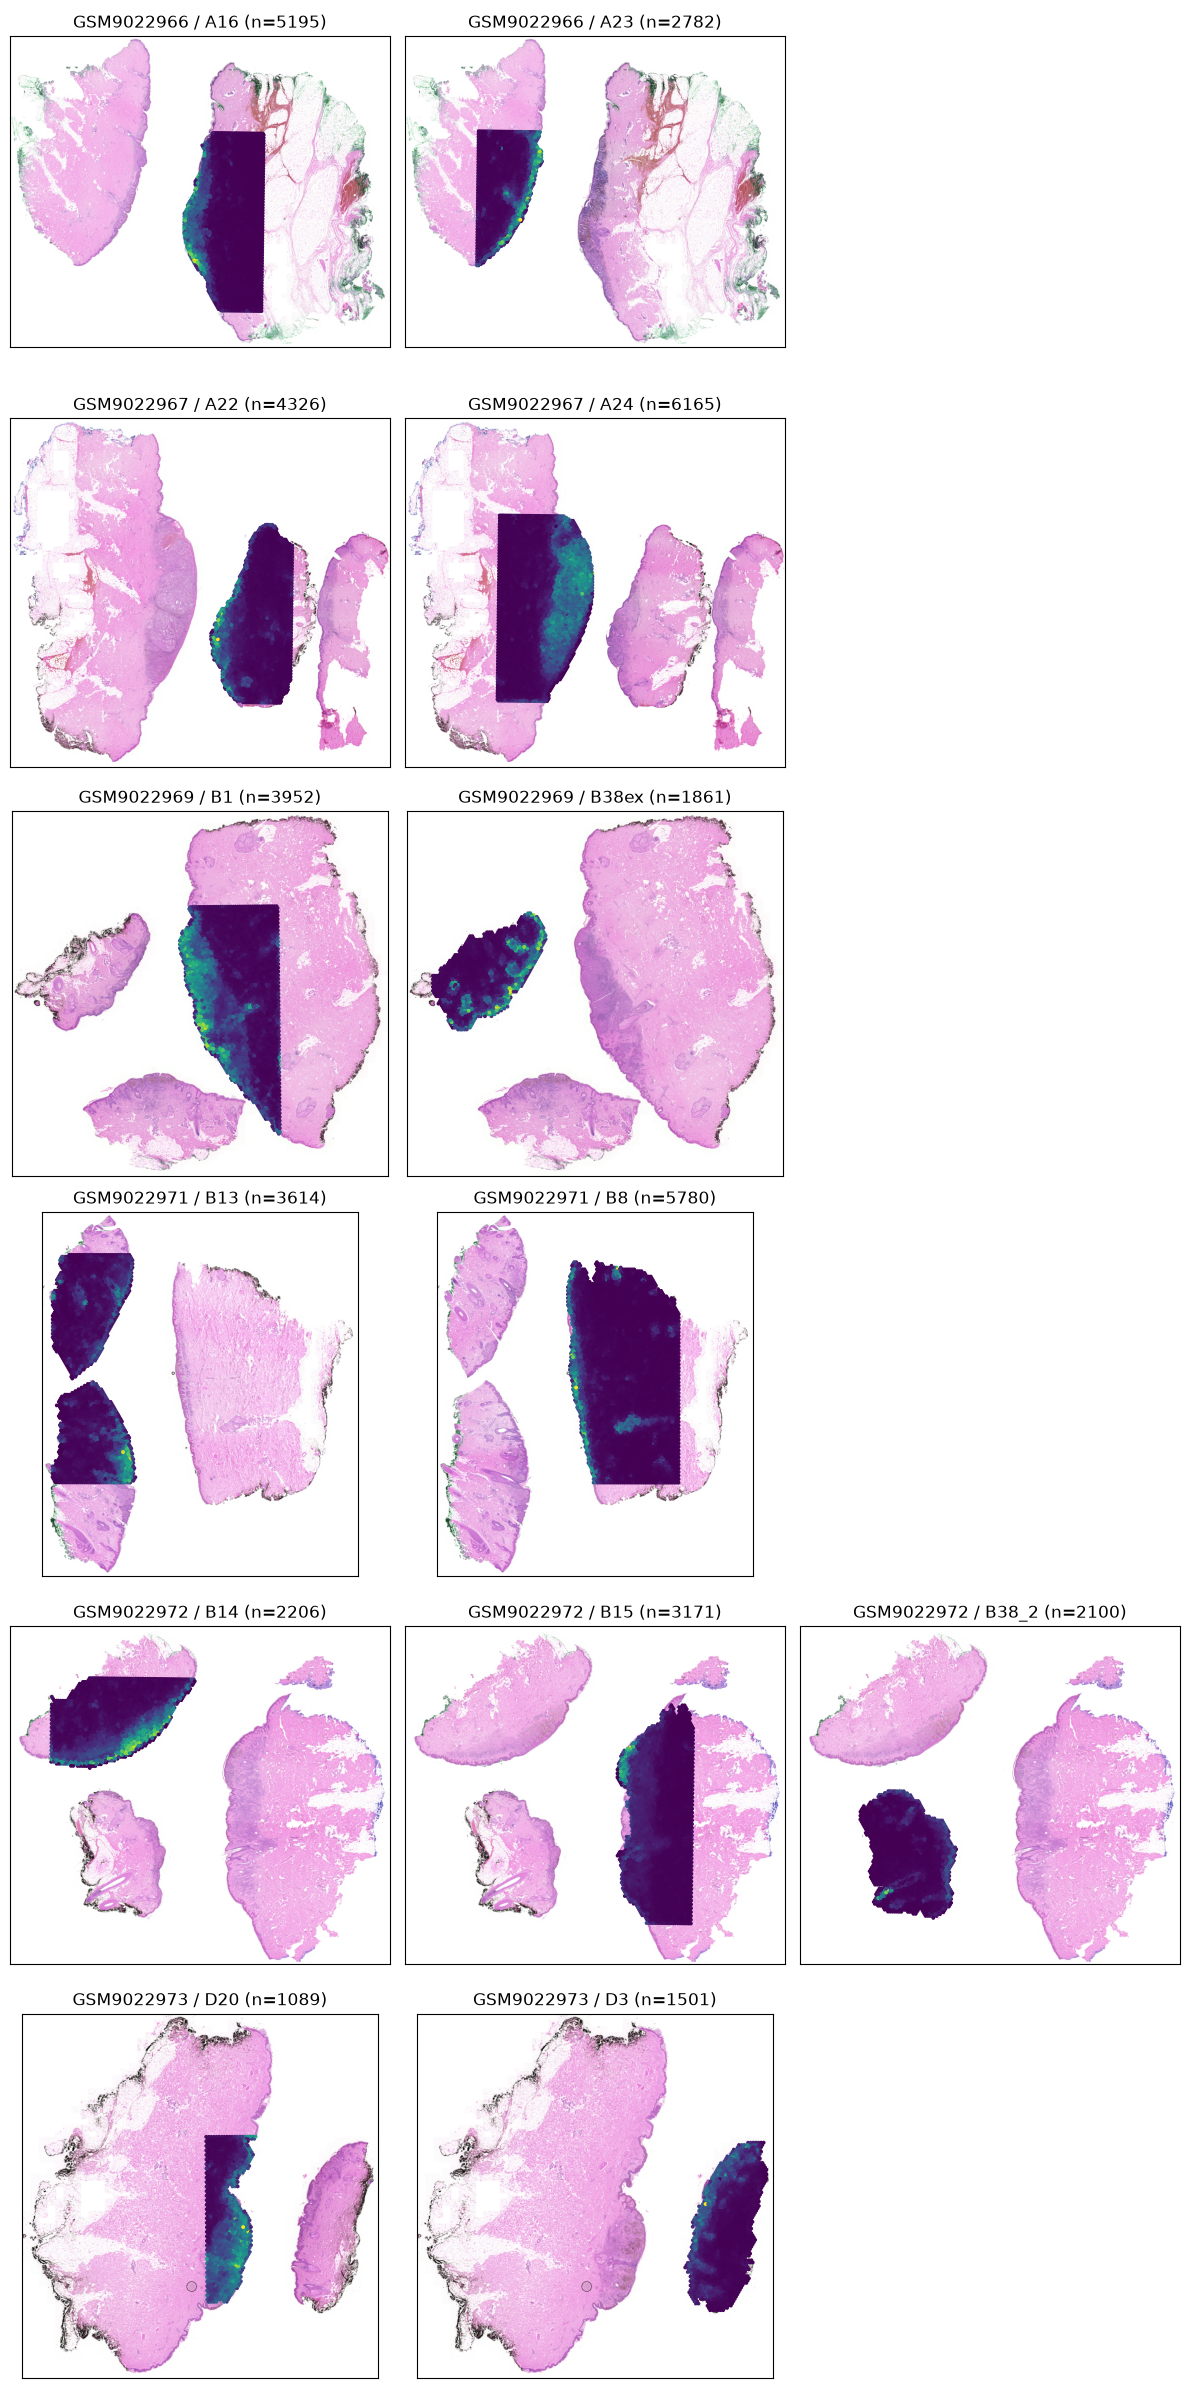

In [13]:
# every other multi-library slide, for context (same color scale isn't meaningful
# across slides given the depth spread in section 6, so each panel uses its own scale)
multi_gsms = [g for g in multi_lib_gsms.index if g != "GSM9022963"]
max_cols = int(multi_lib_gsms.apply(len).max())
fig, axes = plt.subplots(len(multi_gsms), max_cols, figsize=(4 * max_cols, 4 * len(multi_gsms)), squeeze=False)
for row, gsmid in enumerate(multi_gsms):
    libs = sorted(multi_lib_gsms[gsmid])
    for col in range(max_cols):
        ax = axes[row, col]
        if col < len(libs):
            plot_overlay(ax, adatas[libs[col]], f"{gsmid} / {libs[col]}")
        else:
            ax.axis("off")
plt.tight_layout()
plt.savefig(FIGURES_OUT / "01_all_slides_spatial_overlay.png", dpi=150)
plt.show()


## 8. Summary of observations (this notebook only - no interpretation beyond what's plotted/printed above)

In [14]:
print("Observed, from this notebook's own computation:")
print(f"- {len(adatas)}/19 libraries loaded, all matching their own tissue_positions.csv in-tissue count exactly")
print(f"- Feature panels: {dict(panel_counts)}")
print(f"- A2: {n_inferred} spots barcode-recovered from A17, {n_zero_filled} of those have zero detected genes")
print(f"- Depth spread: median genes/spot ranges {library_inventory['median_genes_per_spot'].min():.0f}"
      f" ({library_inventory.iloc[0]['library']}) to {library_inventory['median_genes_per_spot'].max():.0f}"
      f" ({library_inventory.iloc[-1]['library']})")
print(f"- Spots below the 500-gene threshold GEO mentions: "
      f"{int(library_inventory['spots_below_500_genes'].sum())} of {int(library_inventory['n_spots_in_tissue'].sum())} total in-tissue spots")
print(f"- Median mitochondrial %: {library_inventory['median_pct_mito'].min():.1f} - {library_inventory['median_pct_mito'].max():.1f}")
print(f"- Section 7 overlay: A2's spot mask visibly extends past the tissue outline in the image; "
      f"every other library's mask (second figure) hugs its own tissue piece with no equivalent overhang")


Observed, from this notebook's own computation:
- 19/19 libraries loaded, all matching their own tissue_positions.csv in-tissue count exactly
- Feature panels: {37082: np.int64(16), 18085: np.int64(3)}
- A2: 3367 spots barcode-recovered from A17, 42 of those have zero detected genes
- Depth spread: median genes/spot ranges 35 (A2) to 5637 (D20)
- Spots below the 500-gene threshold GEO mentions: 25377 of 65101 total in-tissue spots
- Median mitochondrial %: 2.4 - 5.9
- Section 7 overlay: A2's spot mask visibly extends past the tissue outline in the image; every other library's mask (second figure) hugs its own tissue piece with no equivalent overhang


**Inferred (from the section 7 plots, not proven by a numeric test here):**
A2's overhang beyond the tissue outline, combined with the fact that its
in-tissue signal is concentrated exactly where its mask *does* overlap real
tissue, favors a tissue-boundary/segmentation issue for part of A2's
declared in-tissue region over uniform library failure. This is a visual
read, not a computed one - worth a tighter check (e.g. quantifying spot
signal as a function of distance from the tissue mask edge) before acting on
it in notebook 02.

**Carried into notebook 02 (QC/clustering):** the loader is validated end to
end; QC has to be applied per-library given the depth spread above (not a
single fixed threshold); A2 needs a decision (exclude entirely, or exclude
only its background-looking spots) before it enters any downstream analysis.
Patient (not spot or library) remains the unit of replication for any
cross-lesion comparison (18 patients, 19 libraries).